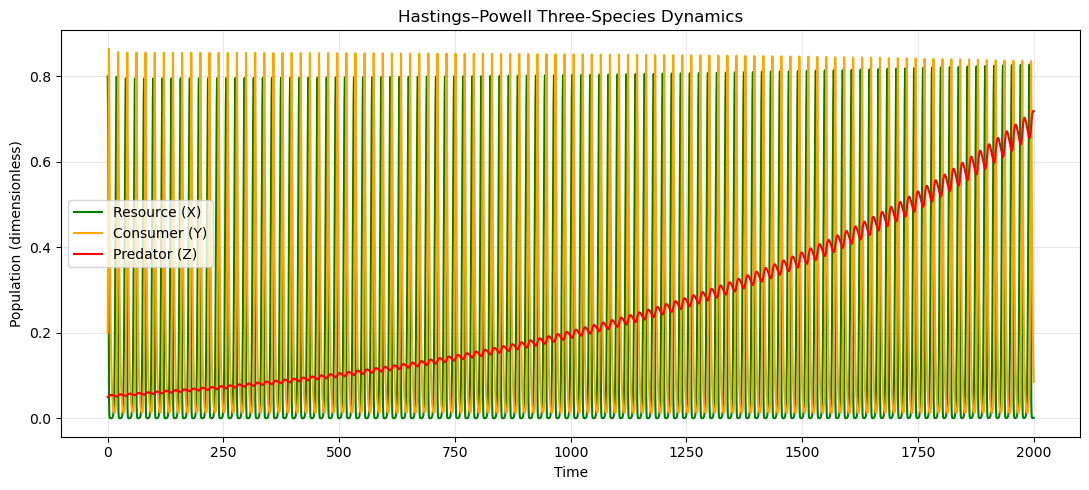

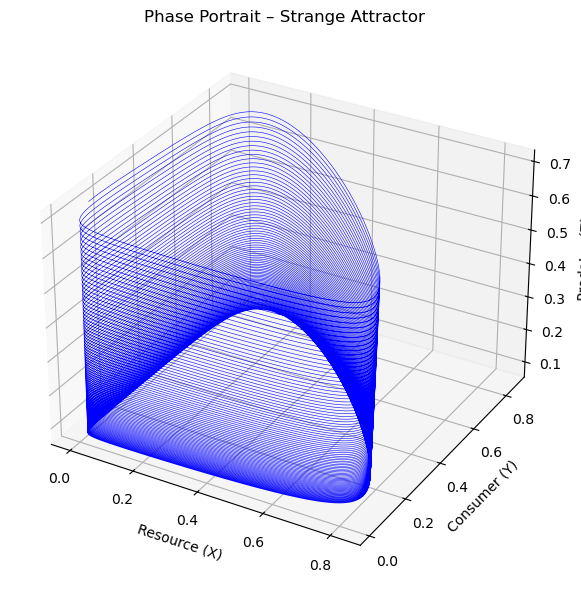

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# HASTINGS–POWELL THREE‑SPECIES MODEL (RESOURCE–CONSUMER–PREDATOR)

def hastings_powell(t, U, p):
    X, Y, Z = U                      # Resource (grass), Consumer (Rabbits), Predator (Foxes)
    a1, b1, a2, b2, d1, d2 = p

    # Type‑II functional responses (Holling)
    f1 = (a1 * X) / (1 + b1 * X)
    f2 = (a2 * Y) / (1 + b2 * Y)

    dXdt = X * (1 - X) - f1 * Y
    dYdt = f1 * Y - f2 * Z - d1 * Y
    dZdt = f2 * Z - d2 * Z

    return np.array([dXdt, dYdt, dZdt])

# Runge–Kutta 4th‑order integrator

def rk4_step(f, t, U, h, p):
    k1 = f(t, U, p)
    k2 = f(t + h/2, U + h/2*k1, p)
    k3 = f(t + h/2, U + h/2*k2, p)
    k4 = f(t + h,   U + h*k3,   p)
    return U + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

def run_solver(f, U0, p, h=0.01, t_end=2000):
    steps = int(t_end/h)
    times = np.linspace(0, t_end, steps)
    sol = np.zeros((steps, 3))
    state = np.array(U0, float)
    for i, t in enumerate(times):
        sol[i] = state
        state = rk4_step(f, t, state, h, p)
        state = np.maximum(state, 0)
    return times, sol

# PARAMETERS FROM HASTINGS–POWELL (CHAOTIC REGIME)
# I tried many different parameters and at one point had many more
# 

params = (5.0, 3.0, 0.1, 2.0, 0.4, 0.01)
U0 = [0.8, 0.2, 0.05]      # initial [Resource, Consumer, Predator]
times, sol = run_solver(hastings_powell, U0, params)
X, Y, Z = sol.T
skip = int(200/0.01)        # drop transients for clean attractor view


# 1. POPULATION‑vs‑TIME PLOT over 2000 time units (chaotic oscillations)


plt.figure(figsize=(11,5))
plt.plot(times, X, color='green',  label='Resource (X)')
plt.plot(times, Y, color='orange', label='Consumer (Y)')
plt.plot(times, Z, color='red',    label='Predator (Z)')
plt.xlabel("Time")
plt.ylabel("Population (dimensionless)")
plt.title("Hastings–Powell Three‑Species Dynamics")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. 3‑D PHASE PORTRAIT

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(X[skip:], Y[skip:], Z[skip:], color='blue', lw=0.4)
ax.set_xlabel("Resource (X)")
ax.set_ylabel("Consumer (Y)")
ax.set_zlabel("Predator (Z)")
ax.set_title("Phase Portrait – Strange Attractor")
plt.tight_layout()
plt.show()
